In [1]:
import sys
import os
sys.path.append('../src')

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# Change to project root directory
os.chdir('..')
print(f"Current directory: {os.getcwd()}")

from src.baseline_model import BaselineModel
from src.kitchen_simulator import KitchenSimulator

plt.style.use('ggplot')
%matplotlib inline

Current directory: c:\Users\imnee\OneDrive\Desktop\kpt-prediction


In [2]:
# Load data
df = pd.read_csv('data/synthetic_orders.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

with open('data/merchant_profiles.json') as f:
    merchants = {m['merchant_id']: m for m in json.load(f)}

print(f"Loaded {len(df)} orders")
print(f"Merchants: {list(merchants.keys())}")

Loaded 10000 orders
Merchants: ['M001', 'M002', 'M003']


In [3]:
# Run baseline simulation
baseline = BaselineModel()
results = []

for idx, order in df.iterrows():
    merchant = merchants[order['merchant_id']]
    result = baseline.simulate_order(order, merchant)
    results.append(result)
    
    if idx % 1000 == 0:
        print(f"Processed {idx} orders...")

baseline_results = pd.DataFrame(results)
baseline_results.to_csv('results/baseline_results.csv', index=False)
print("\n✓ Saved baseline_results.csv")

Processed 0 orders...
Processed 1000 orders...
Processed 2000 orders...
Processed 3000 orders...
Processed 4000 orders...
Processed 5000 orders...
Processed 6000 orders...
Processed 7000 orders...
Processed 8000 orders...
Processed 9000 orders...

✓ Saved baseline_results.csv


In [4]:
# Calculate metrics
metrics = {
    'avg_rider_wait': baseline_results['rider_wait'].mean(),
    'p50_eta_error': baseline_results['eta_error'].quantile(0.5),
    'p90_eta_error': baseline_results['eta_error'].quantile(0.9),
    'delay_rate': baseline_results['is_delayed'].mean(),
    'avg_idle_time': baseline_results['rider_wait'].mean() + 4
}

print("\n=== BASELINE METRICS ===")
for key, value in metrics.items():
    print(f"{key}: {value:.2f}")


=== BASELINE METRICS ===
avg_rider_wait: 1.70
p50_eta_error: 2.09
p90_eta_error: 7.70
delay_rate: 0.13
avg_idle_time: 5.70


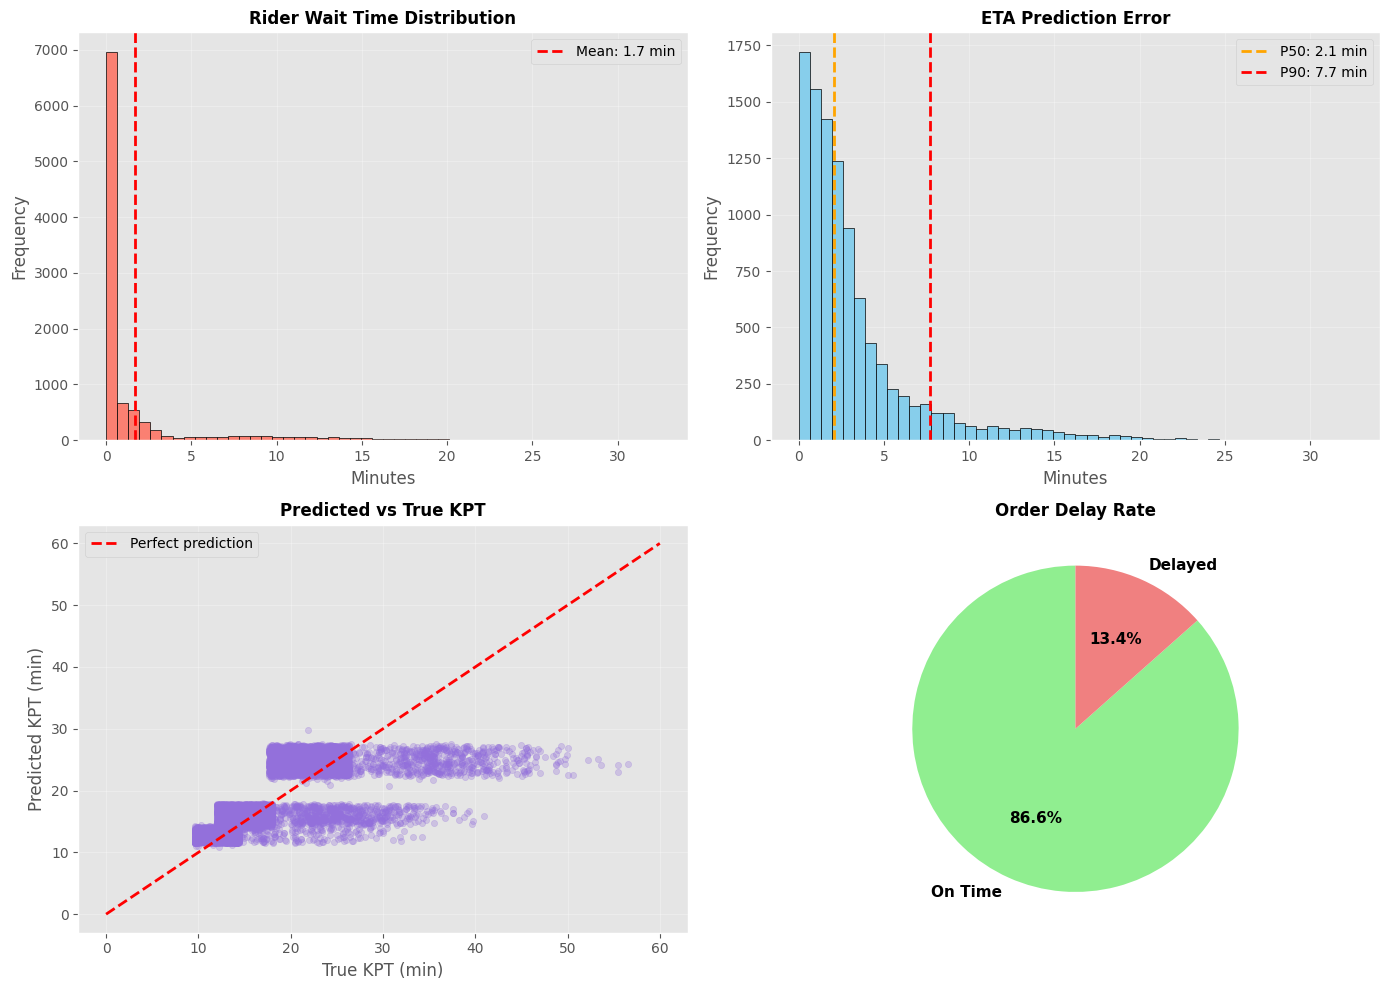

✓ Saved: results/baseline_analysis.png


In [5]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Wait time distribution
axes[0,0].hist(baseline_results['rider_wait'], bins=50, edgecolor='black', color='salmon')
axes[0,0].axvline(metrics['avg_rider_wait'], color='red', linestyle='--', linewidth=2, label=f"Mean: {metrics['avg_rider_wait']:.1f} min")
axes[0,0].set_title('Rider Wait Time Distribution', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Minutes')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# ETA error
axes[0,1].hist(baseline_results['eta_error'], bins=50, edgecolor='black', color='skyblue')
axes[0,1].axvline(metrics['p50_eta_error'], color='orange', linestyle='--', linewidth=2, label=f"P50: {metrics['p50_eta_error']:.1f} min")
axes[0,1].axvline(metrics['p90_eta_error'], color='red', linestyle='--', linewidth=2, label=f"P90: {metrics['p90_eta_error']:.1f} min")
axes[0,1].set_title('ETA Prediction Error', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Minutes')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Predicted vs True
axes[1,0].scatter(baseline_results['true_kpt'], baseline_results['predicted_kpt'], alpha=0.3, color='mediumpurple', s=20)
axes[1,0].plot([0, 60], [0, 60], 'r--', linewidth=2, label='Perfect prediction')
axes[1,0].set_title('Predicted vs True KPT', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('True KPT (min)')
axes[1,0].set_ylabel('Predicted KPT (min)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Delay rate pie
delay_counts = baseline_results['is_delayed'].value_counts()
colors = ['lightgreen', 'lightcoral']
axes[1,1].pie(delay_counts, labels=['On Time', 'Delayed'], autopct='%1.1f%%', 
              colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1,1].set_title('Order Delay Rate', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/baseline_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: results/baseline_analysis.png")